# EDA Air Pollution

In [1]:
# Import the required libraries.
import yaml
import joblib
import numpy as np
import pandas as pd

# Need to be installed.
import seaborn as sns
import scipy.stats as scs
import matplotlib.pyplot as plt

## 1 - Configuration File

In [2]:
def load_config(config_path):
    """
    Load the configuration file.

    Parameters:
    --------------
    config_path : str
        Configuration file location

    Returns:
    --------------
    params : dict
        Loaded configuration file
    """

    try:
        with open(config_path,'r') as file:
            params = yaml.safe_load(file)
    except FileNotFoundError as err:
        raise RuntimeError(f"Configuration file not found in {config_path}")

    return params

In [3]:
def load_config(config_path):
    """
    Load the configuration file.

    Parameters:
    --------------
    config_path : str
        Configuration file location

    Returns:
    --------------
    params : dict
        Loaded configuration file
    """

    try:
        with open(config_path,'r') as file:
            params = yaml.safe_load(file)
    except FileNotFoundError as err:
        raise RuntimeError(f"Configuration file not found in {config_path}")

    return params

In [4]:
PATH_CONFIG = "../config/config.yaml"
config = load_config(PATH_CONFIG)
config

{'columns_datetime': ['tanggal'],
 'columns_int': ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max'],
 'columns_object': ['stasiun', 'critical', 'category'],
 'features': ['stasiun', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2'],
 'label': 'category',
 'label_categories': ['BAIK', 'SEDANG', 'TIDAK SEHAT'],
 'label_categories_new': ['BAIK', 'TIDAK BAIK'],
 'path_joined_data': '../data/interim/joined_dataset.pkl',
 'path_raw_data': '../data/raw/',
 'path_test_set': ['../data/interim/X_test.pkl', '../data/interim/y_test.pkl'],
 'path_train_set': ['../data/interim/X_train.pkl',
  '../data/interim/y_train.pkl'],
 'path_valid_set': ['../data/interim/X_valid.pkl',
  '../data/interim/y_valid.pkl'],
 'path_validated_data': '../data/interim/validated_data.pkl',
 'range_co': [-1, 47],
 'range_no2': [-1, 65],
 'range_o3': [-1, 151],
 'range_pm10': [-1, 179],
 'range_pm25': [-1, 174],
 'range_so2': [-1, 82],
 'range_stasiun': ['DKI1 (Bunderan HI)',
  'DKI2 (Kelapa Gading)',
  'DKI3 (Jagakarsa)',
  'DKI4

## 2 Load data

In [5]:
X_train = joblib.load(config['path_train_set'][0])
y_train = joblib.load(config['path_train_set'][1])

In [6]:
dataset = pd.concat([X_train,y_train],axis=1)

In [7]:
dataset.head()

,stasiun,pm10,pm25,so2,co,o3,no2,category
274,DKI5 (Kebon Jeruk) Jakarta Barat,27,55,27,5,20,8,SEDANG
1713,DKI2 (Kelapa Gading),52,65,28,16,41,15,SEDANG
1041,DKI5 (Kebon Jeruk) Jakarta Barat,30,56,24,7,39,12,SEDANG
173,DKI1 (Bunderan HI),30,42,22,10,9,16,BAIK
1560,DKI2 (Kelapa Gading),78,104,54,10,63,17,TIDAK SEHAT


## 3 - Exploratory Data Analysis

1. Missing Value Check
2. Skewness Check
3. Data Split
4. Visualization
5. Hypothesis Test
6. Imbalanced Label Check
7. Outliers Check

### 3.1 Missing Value Check

In [8]:
# Replace the -1 values with NaN.
dataset = dataset.replace(-1, np.nan)

In [9]:
dataset.isnull().sum()

stasiun      0
pm10        36
pm25        69
so2         72
co          13
o3          37
no2         16
category     0
dtype: int64

### 3.2 Skewness Check

In [10]:
# Fisher-Pearson Skew values.
dataset.skew(numeric_only=True)

pm10    0.205337
pm25    0.329907
so2     0.208410
co      1.873707
o3      1.256036
no2     0.873289
dtype: float64

**Insights:**

- pm10 is left skewed, but not significant. The rest are right skewed.
- co, o3, and no2 have skew values > 0.5  , indicating a lot of outliers. We will impute using it's median.
- The rest will be imputed using it's mean.

### 3.3 Data Split

In [11]:
dataset_baik = dataset[dataset["category"] == "BAIK"].copy()
dataset_tidak_baik = dataset[dataset["category"] != "BAIK"].copy()

In [12]:
# Kelas 1 => BAIK.
dataset_baik.describe()

,pm10,pm25,so2,co,o3,no2
count,143.000000,111.000000,148.000000,151.000000,148.000000,140.000000
mean,28.468531,39.675676,25.702703,8.933775,25.932432,11.335714
std,7.506621,8.372207,10.498759,4.321526,11.134711,6.829486
min,14.000000,13.000000,3.000000,2.000000,7.000000,3.000000
25%,23.000000,34.000000,18.000000,6.000000,16.000000,6.000000
50%,28.000000,41.000000,23.500000,8.000000,24.000000,10.000000
75%,33.000000,47.000000,34.500000,11.000000,35.250000,15.000000
max,50.000000,50.000000,50.000000,28.000000,49.000000,49.000000


In [13]:

# Kelas 0 => SEDANG & TIDAK SEHAT
dataset_tidak_baik.describe()

,pm10,pm25,so2,co,o3,no2
count,1271.000000,1270.000000,1230.000000,1286.000000,1265.000000,1294.000000
mean,55.559402,82.799213,36.383740,11.944012,32.435573,20.221020
std,13.357686,22.061734,12.299056,4.954577,14.345229,8.780682
min,19.000000,19.000000,5.000000,3.000000,9.000000,1.000000
25%,49.000000,68.000000,27.000000,9.000000,23.000000,14.000000
50%,56.000000,81.000000,37.000000,11.000000,29.000000,19.000000
75%,63.000000,96.000000,45.000000,14.000000,39.000000,25.750000
max,179.000000,174.000000,82.000000,47.000000,134.000000,65.000000


**Insights:**

- pm10 and pm25 mean between class 0 and 1 have a significant difference. We will impute using class mean.
- so2 mean between class 0 and 1 have a slight difference. We will be impute using the mean.
- co, o3, and no2 median between class 0 and 1 have a slight difference. We will impute using the median.

### 3.4 Visualization

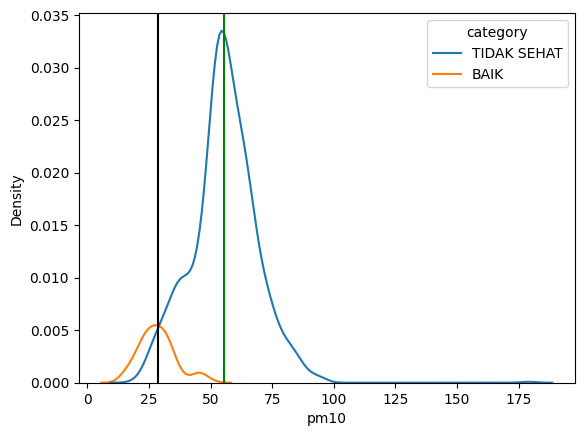

In [14]:
# pm10 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "pm10",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["pm10"].mean(), 0, 1, color='g')
plt.axvline(dataset_baik["pm10"].mean(), 0, 1, color='k')
plt.show()

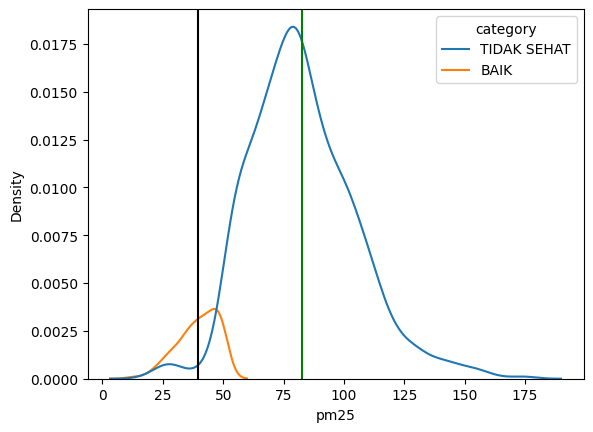

In [15]:
# pm25 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "pm25",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["pm25"].mean(), 0, 1, color='g')
plt.axvline(dataset_baik["pm25"].mean(), 0, 1, color='k')
plt.show()

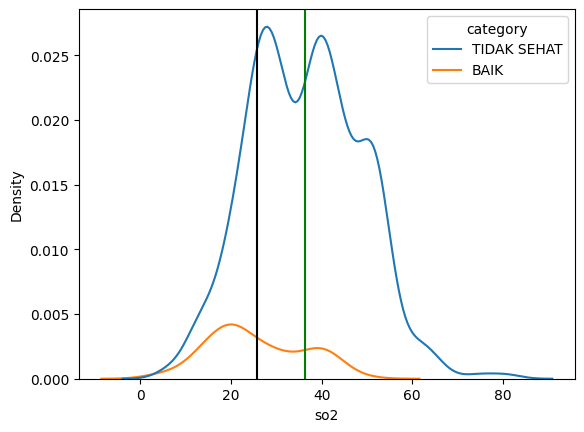

In [16]:
# so2 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "so2",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["so2"].mean(), 0, 1, color='g')
plt.axvline(dataset_baik["so2"].mean(), 0, 1, color='k')
plt.show()

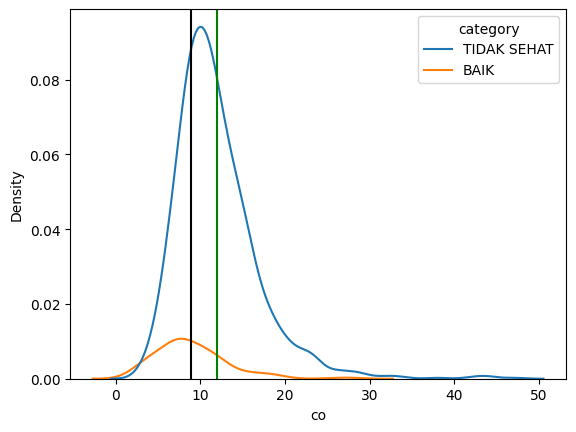

In [17]:
# co column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "co",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["co"].mean(), 0, 1, color='g')
plt.axvline(dataset_baik["co"].mean(), 0, 1, color='k')
plt.show()

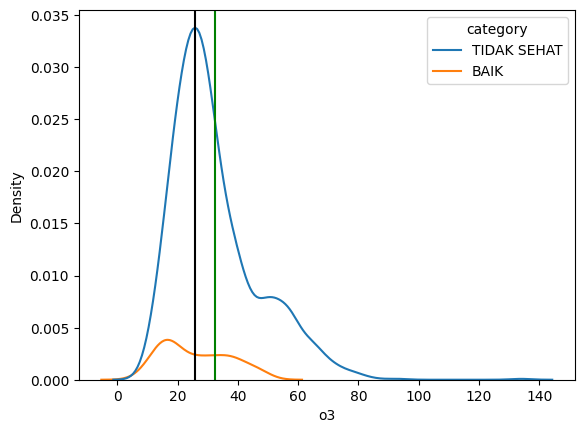

In [18]:
# o3 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "o3",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["o3"].mean(), 0, 1, color='g')
plt.axvline(dataset_baik["o3"].mean(), 0, 1, color='k')
plt.show()

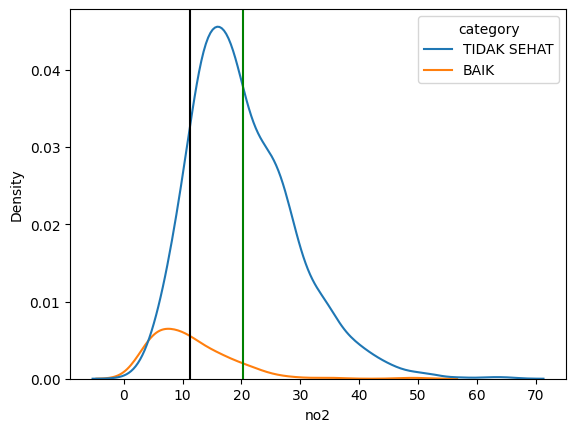

In [19]:
# no2 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "no2",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["no2"].mean(), 0, 1, color='g')
plt.axvline(dataset_baik["no2"].mean(), 0, 1, color='k')
plt.show()

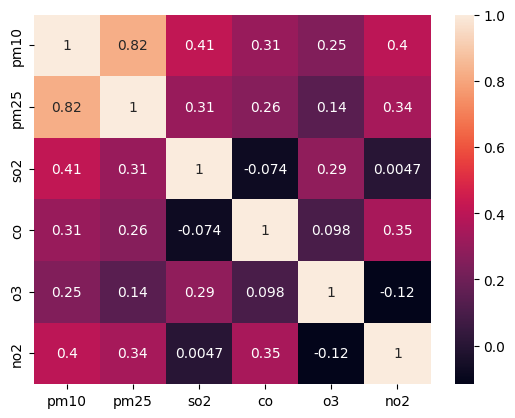

In [20]:
# Pearson Correlation.
sns.heatmap(
    dataset.corr(numeric_only=True),
    annot=True
)
plt.show()

### **3.5. Hypothesis Test**
---
T-Test (to check mean between 2 variables)

**Note:**
- $h_0$ (null hypothesis): mean of class 0 == mean of class 1.
- $h_1$ (alternative hypothesis): mean of class 0 != mean of class 1.
- $h_0$ and $h_1$ is *mutually exclusive* (if $h_0$ is true, $h_1$ is false, and vice versa).
- The goal of the test is to determine whether to reject the $h_0$.

In [21]:
# pm10 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["pm10"].isnull() != True].pm10,
    dataset_tidak_baik[dataset_tidak_baik["pm10"].isnull() != True].pm10
)

TtestResult(statistic=np.float64(-23.82801606987733), pvalue=np.float64(9.333010904969523e-106), df=np.float64(1412.0))

In [22]:
# t-critical for alpha=0.05 and dof=n-2
scs.t.ppf(0.05, df=(len(dataset) - 2))

np.float64(-1.6459066313849768)

**Insights:**
- If $t_{value} < t_{critical}$ and $p_{value} < 0.05$, then $h_0$ is rejected.
- Summary: `pm10` mean between class 0 and class 1 is statistically significant.

In [23]:
# pm25 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["pm25"].isnull() != True].pm25,
    dataset_tidak_baik[dataset_tidak_baik["pm25"].isnull() != True].pm25
)

TtestResult(statistic=np.float64(-20.459669763113553), pvalue=np.float64(1.8471949815092773e-81), df=np.float64(1379.0))

In [24]:
# so2 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["so2"].isnull() != True].so2,
    dataset_tidak_baik[dataset_tidak_baik["so2"].isnull() != True].so2
)

TtestResult(statistic=np.float64(-10.129494364428005), pvalue=np.float64(2.6219032812528867e-23), df=np.float64(1376.0))

### **3.6. Imbalanced Label Check**

In [25]:
# Check the proportion of the label.
dataset["category"].value_counts(normalize=True)

category
SEDANG         0.720000
TIDAK SEHAT    0.175862
BAIK           0.104138
Name: proportion, dtype: float64

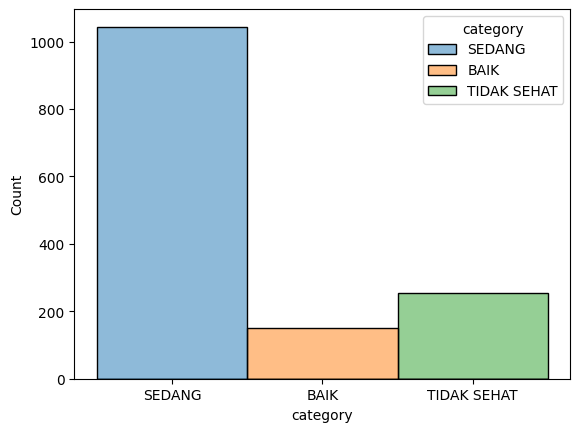

In [26]:
sns.histplot(
    data = dataset,
    x = "category",
    hue="category"
)
plt.show()

### **3.7. Outliers Check**

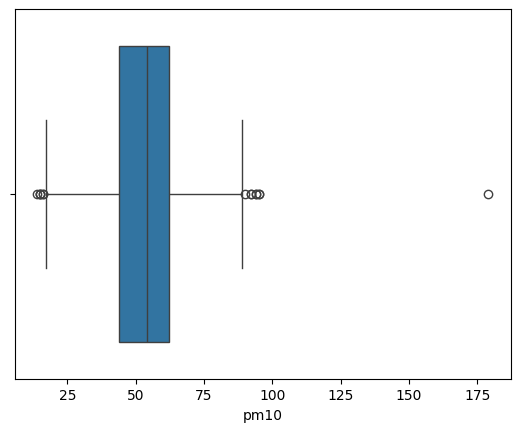

In [27]:
# pm10 boxplot.
sns.boxplot(
    data = dataset,
    x = "pm10"
)
plt.show()

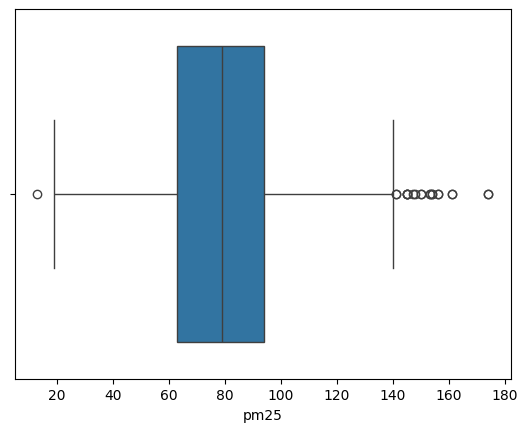

In [28]:
# pm25 boxplot.
sns.boxplot(
    data = dataset,
    x = "pm25"
)
plt.show()

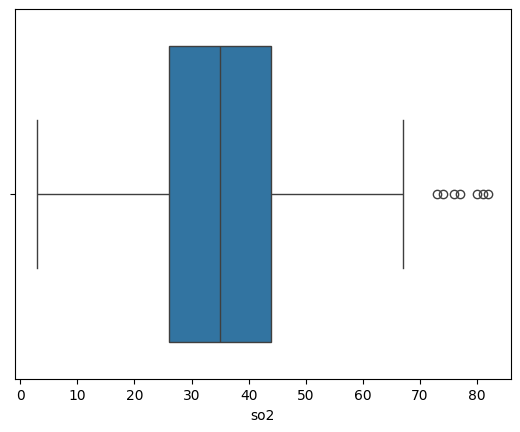

In [29]:
# so2 boxplot.
sns.boxplot(
    data = dataset,
    x = "so2"
)
plt.show()

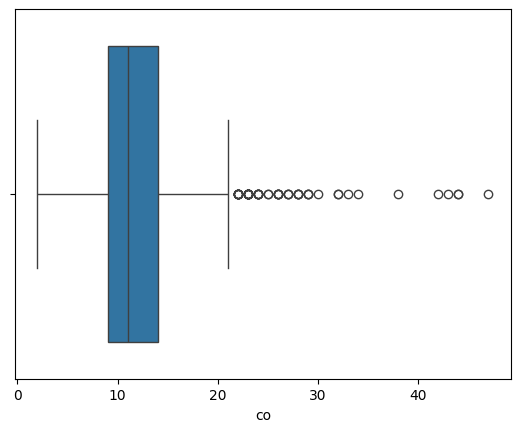

In [30]:
# co boxplot.
sns.boxplot(
    data = dataset,
    x = "co"
)
plt.show()

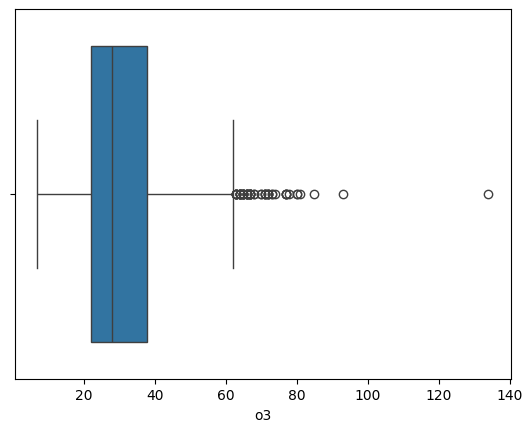

In [31]:
# o3 boxplot.
sns.boxplot(
    data = dataset,
    x = "o3"
)
plt.show()

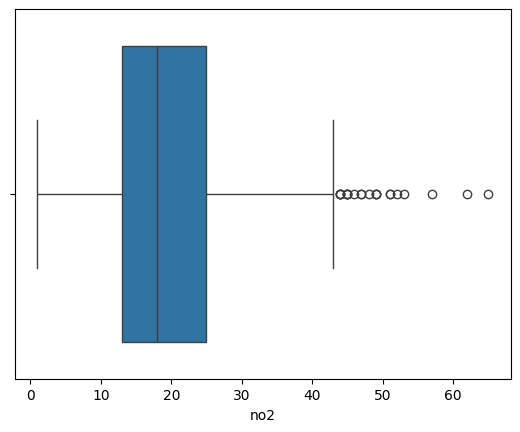

In [32]:
# no2 boxplot.
sns.boxplot(
    data = dataset,
    x = "no2"
)
plt.show()

**Summary:**
1. Missing Value Handling
   - `pm10` and `pm25` : class mean
   - `so2` : mean
   - `co`, `o3`, and `no2` : median
3. Join label `SEDANG` and `TIDAK SEHAT` into `TIDAK BAIK`
4. Label balancing `BAIK` and `TIDAK BAIK`
5. Outliers removal